In [30]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from hmmlearn import hmm
from pykalman import KalmanFilter
import seaborn as sns
import os
import warnings
import xgboost as xgb

warnings.filterwarnings('ignore')

# global variables
START_DATE = '1927-12-30'
END_DATE = '2025-03-31' 
SYMBOL = '^GSPC'
WINDOW_SIZES = [5, 10, 20, 30, 50, 100, 200, 300, 500, 1000]

# folder to store results
os.makedirs('results', exist_ok=True)


In [31]:
# dataset download function
def download_data():
    filename = 'sp500_prices.csv'
    if os.path.exists(filename):
        print(f"{filename} already exists.")
        return filename
    data = yf.download(SYMBOL, start=START_DATE, end=END_DATE)
    if 'Adj Close' not in data.columns:
        data['Adj Close'] = data['Close']
    data['Adj Close'].fillna(method='ffill', inplace=True)
    data[['Adj Close']].to_csv(filename)
    print(f"Data saved to {filename}")
    return filename

In [32]:
# data load and to plot
def load_data(filepath):
    df = pd.read_csv(filepath, index_col=0, parse_dates=True)
    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df['Adj Close'])
    plt.title('S&P 500 Price History')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.grid(True)
    plt.savefig('sp500_price_history.png', dpi=300)
    plt.close()
    return df

In [33]:
# calculating MAPE and sampling
def calculate_mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(100 * np.abs((actual[mask] - predicted[mask]) / actual[mask]))

def sample_prices(prices, window):
    if window <= 100:
        return prices
    elif window <= 300:
        return prices[::2]
    elif window <= 500:
        return prices[::5]
    return prices[::10]

In [34]:
# HMM model prediction
def predict_hmm(prices, window):
    print(f"Running HMM with window {window}...")
    sampled = sample_prices(prices, window)
    returns = np.diff(sampled) / sampled[:-1]
    returns = np.nan_to_num(returns)

    n_states = 5 if window <= 100 else 3
    cov_type = "full" if window <= 100 else "diag"

    X = np.array([returns[i:i+window] for i in range(len(returns) - window)])
    X = np.nan_to_num(X)
    if len(X) == 0 or np.isnan(X).any():
        return 100

    model = hmm.GaussianHMM(n_components=n_states, covariance_type=cov_type, n_iter=10, random_state=0)
    try:
        model.fit(X[:300])  # limiting training to 300
    except Exception as e:
        print(f"  HMM error: {e}")
        return 100

    predictions, actual = [], []
    for i in range(window, min(len(returns)-1, 300)):
        current = returns[i-window:i]
        current = np.nan_to_num(current)
        try:
            state = model.predict([current])[0]
            pred_return = np.mean(model.means_[state])
        except:
            pred_return = np.mean(current)
        pred_price = sampled[i] * (1 + pred_return)
        predictions.append(pred_price)
        actual.append(sampled[i+1])
    return calculate_mape(actual, predictions)

In [35]:
# kalman filter model prediction
def predict_kalman(prices, window):
    print(f"Running Kalman Filter with window {window}...")
    sampled = sample_prices(prices, window)
    predictions, actual = [], []

    for i in range(window, min(len(sampled)-1, 300)):
        train = sampled[i-window:i]
        train = np.nan_to_num(train)
        kf = KalmanFilter(initial_state_mean=train[0], transition_matrices=[1],
                          observation_matrices=[1], observation_covariance=0.1,
                          transition_covariance=0.01)
        try:
            state_means, _ = kf.filter(train)
            pred_price = state_means[-1][0]
        except:
            pred_price = np.mean(train)
        predictions.append(pred_price)
        actual.append(sampled[i+1])
    return calculate_mape(actual, predictions)

In [36]:
# DBN model prediction
def predict_dbn(prices, window):
    print(f"Running DBN with window {window}...")
    sampled = sample_prices(prices, window)
    returns = np.diff(sampled) / sampled[:-1]
    returns = np.nan_to_num(returns)
    states = np.digitize(returns, bins=[-0.001, 0.001])
    predictions, actual = [], []

    for i in range(window, min(len(states)-1, 300)):
        window_states = states[i-window:i]
        transitions = np.zeros((3, 3))
        for j in range(len(window_states)-1):
            transitions[window_states[j], window_states[j+1]] += 1
        probs = np.array([row / row.sum() if row.sum() > 0 else np.ones(3)/3 for row in transitions])
        current = states[i-1]
        next_state = np.argmax(probs[current])
        pred_return = {-1: -0.01, 0: 0, 1: 0.01}.get(next_state - 1, 0)
        pred_price = sampled[i] * (1 + pred_return)
        predictions.append(pred_price)
        actual.append(sampled[i+1])
    return calculate_mape(actual, predictions)

In [37]:
# XGBoost model prediction
def predict_xgboost(prices, window):
    print(f"Running XGBoost with window {window}...")
    sampled = sample_prices(prices, window)
    
    X = []
    y = []
    for i in range(window, len(sampled)):
        X.append(sampled[i-window:i])  # previous window prices as input 
        y.append(sampled[i])  # target variable is price at the next time instance
    
    X = np.array(X)
    y = np.array(y)
    
    # initializing XGBoost model
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    model.fit(X, y)
    
    # predict using the model
    predictions = model.predict(X)
    
    return calculate_mape(y, predictions)

In [38]:
def run_models(prices):
    results = {'Window Size': [], 'HMM': [], 'Kalman': [], 'DBN': [], 'XGBoost': []}
    for window in WINDOW_SIZES:
        if window >= len(prices) - 1:
            print(f"Skipping window {window}, too large.")
            continue
        
        # calculating MAPE for all 4 models
        hmm_mape = predict_hmm(prices, window)
        kalman_mape = predict_kalman(prices, window)
        dbn_mape = predict_dbn(prices, window)
        xgb_mape = predict_xgboost(prices, window)
        
        # storing results
        results['Window Size'].append(window)
        results['HMM'].append(hmm_mape)
        results['Kalman'].append(kalman_mape)
        results['DBN'].append(dbn_mape)
        results['XGBoost'].append(xgb_mape)
        
        # saving results 
        pd.DataFrame(results).to_csv(f'results/results_window_{window}.csv', index=False)
    
    return pd.DataFrame(results).set_index('Window Size')


In [39]:
# visualizing results
def visualize_results_all_models(df):
    # plot for comparison - MAPE vs n
    plt.figure(figsize=(12, 6))
    df.plot(marker='o')
    plt.title('Prediction Accuracy by Window Size (MAPE %)')
    plt.ylabel('Average MAPE (%)')
    plt.xlabel('Window Size')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('prediction_accuracy_all_models.png', dpi=300)  # saving plot
    plt.show()

    # bar chart for comparison 
    plt.figure(figsize=(12, 6))
    df.plot(kind='bar', width=0.8)
    plt.title('Model Comparison by Window Size')
    plt.ylabel('Average MAPE (%)')
    plt.xlabel('Window Size')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig('model_comparison_all_models_bar.png', dpi=300)  
    plt.show()  

    # Heatmap 
    plt.figure(figsize=(10, 6))
    sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title('MAPE Heatmap by Model and Window Size')
    plt.tight_layout()
    plt.savefig('error_heatmap_all_models.png', dpi=300)  
    plt.show()  


Starting S&P 500 Prediction Project...
sp500_prices.csv already exists.
Running HMM with window 5...


Model is not converging.  Current: 4881.202864674484 is not greater than 4892.219494973429. Delta is -11.016630298945529


Running Kalman Filter with window 5...
Running DBN with window 5...
Running XGBoost with window 5...
Running HMM with window 10...


Model is not converging.  Current: 9963.397889812022 is not greater than 9973.281300852099. Delta is -9.88341104007668


Running Kalman Filter with window 10...
Running DBN with window 10...
Running XGBoost with window 10...
Running HMM with window 20...
Running Kalman Filter with window 20...
Running DBN with window 20...
Running XGBoost with window 20...
Running HMM with window 30...


...

Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.


Running HMM with window 1000...


Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.


Running Kalman Filter with window 1000...
Running DBN with window 1000...
Running XGBoost with window 1000...


<Figure size 960x480 with 0 Axes>

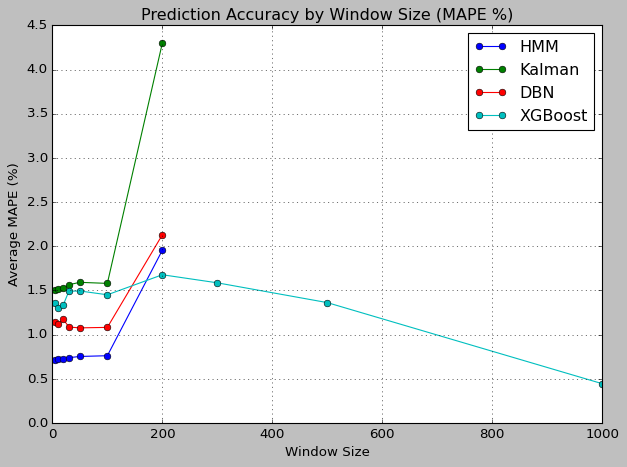

<Figure size 960x480 with 0 Axes>

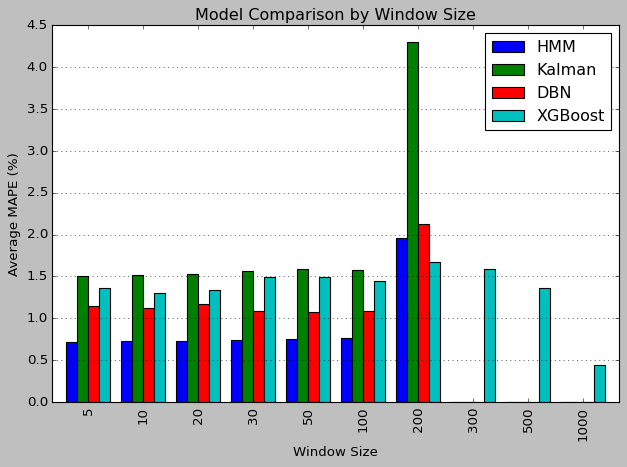

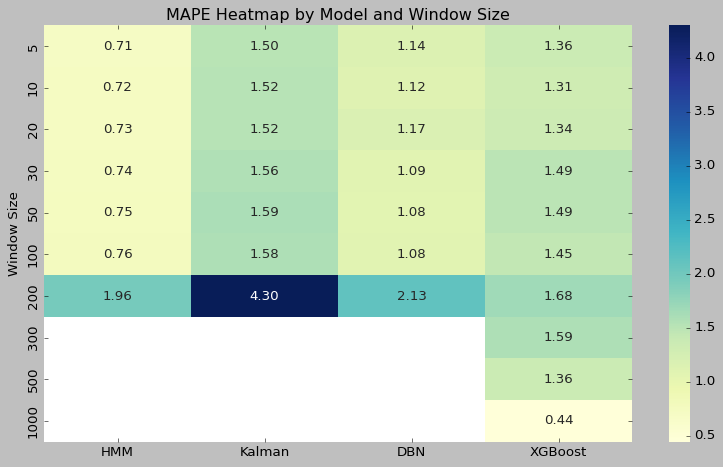

Project completed successfully.


In [40]:
if __name__ == '__main__':
    print("Starting S&P 500 Prediction Project...")
    csv_file = download_data()
    df = load_data(csv_file)
    prices = df['Adj Close'].values
    results_df = run_models(prices) 
    visualize_results_all_models(results_df)
    print("Project completed successfully.")